In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset
data = pd.read_csv('../dataset/avito_voitures 18.csv', 
                   sep=',', 
                   on_bad_lines='skip') 
data.columns = data.columns.str.replace(' ', '_')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18893 entries, 0 to 18892
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Titre              18893 non-null  object 
 1   Prix               14057 non-null  object 
 2   Date_d'ajout       18893 non-null  object 
 3   Localisation       18893 non-null  object 
 4   Annee              18829 non-null  object 
 5   Auto_manuel        18829 non-null  object 
 6   Carburant          18829 non-null  object 
 7   Type               14321 non-null  object 
 8   Secteur            14321 non-null  object 
 9   Kilomtrage         14321 non-null  object 
 10  Marque             14321 non-null  object 
 11  Module             14321 non-null  object 
 12  Nombre_de_portes   14321 non-null  float64
 13  Origine            14321 non-null  object 
 14  Première_main      14321 non-null  object 
 15  Puissance_fiscale  14321 non-null  object 
 16  Eat                143

In [2]:
# Supprimer les lignes dupliquées
before = data.shape[0]
data = data.drop_duplicates()
after = data.shape[0]
print(before)
print(after)

18893
18103


In [3]:
# GESTION DES VALEURS MANQUANTES

data['Prix'] = data['Prix'].astype(str).str.replace('DH', '', regex=False)
data['Prix'] = data['Prix'].str.replace(' ', '', regex=False)
data['Prix'] = pd.to_numeric(data['Prix'], errors='coerce')  # Remplace les erreurs par NaN
data['Prix'] = data['Prix'].fillna(data['Prix'].median()) # Remplacer les vals manquantes par la mediane

data['Annee'] = pd.to_numeric(data['Annee'], errors='coerce')
data['Annee']= data['Annee'].fillna(data['Annee'].median()) # Remplacer les vals manquantes par la mediane

data['Auto_manuel']= data['Auto_manuel'].fillna(data['Auto_manuel'].mode()[0])

data['Carburant']= data['Carburant'].fillna(data['Carburant'].mode()[0])

data['Type']= data['Type'].fillna(data['Type'].mode()[0])

data['Secteur']= data['Secteur'].fillna(data['Secteur'].mode()[0])

data['Kilomtrage'] = data['Kilomtrage'].astype(str).str.replace(' ', '', regex=True)
kilomtrage_split = data['Kilomtrage'].str.split('-', expand=True)
if kilomtrage_split.shape[1] == 1:
    kilomtrage_split[1] = kilomtrage_split[0]  # Si pas de '-', on met la même valeur
kilomtrage_split = kilomtrage_split.apply(pd.to_numeric, errors='coerce')
data['Kilomtrage'] = kilomtrage_split.mean(axis=1)
data['Kilomtrage'] = data['Kilomtrage'].fillna(data['Kilomtrage'].median())

data['Marque']= data['Marque'].fillna(data['Marque'].mode()[0])

data['Module']= data['Module'].fillna(data['Module'].mode()[0])

data['Nombre_de_portes']= data['Nombre_de_portes'].fillna(data['Nombre_de_portes'].median())

data['Origine']= data['Origine'].fillna(data['Origine'].mode()[0])

data['Première_main']= data['Première_main'].fillna(data['Première_main'].mode()[0])

data['Puissance_fiscale'] = data['Puissance_fiscale'].astype(str).str.replace('CV', '', regex=False)
data['Puissance_fiscale'] = data['Puissance_fiscale'].str.replace(' ', '', regex=False)
data['Puissance_fiscale'] = pd.to_numeric(data['Puissance_fiscale'], errors='coerce') 
data['Puissance_fiscale']= data['Puissance_fiscale'].fillna(data['Puissance_fiscale'].median())

data['Eat']= data['Eat'].fillna(data['Eat'].mode()[0])
    
print(data.isnull().sum())



Titre                0
Prix                 0
Date_d'ajout         0
Localisation         0
Annee                0
Auto_manuel          0
Carburant            0
Type                 0
Secteur              0
Kilomtrage           0
Marque               0
Module               0
Nombre_de_portes     0
Origine              0
Première_main        0
Puissance_fiscale    0
Eat                  0
dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder

# Liste des colonnes catégorielles à encoder
categorical_cols = ['Localisation', 'Auto_manuel', 'Carburant', 'Type', 'Secteur', 
                    'Marque', 'Module', 'Origine', 'Première_main', 'Eat']

# Initialiser un dictionnaire pour stocker les encodeurs (utile si tu veux les réutiliser plus tard)
label_encoders = {}

# Appliquer LabelEncoder à chaque colonne catégorielle
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le  # On garde l’encodeur si on veut transformer de nouvelles données plus tard

# Le DataFrame `data` contient maintenant les colonnes encodées


In [5]:
import numpy as np

# Colonnes à transformer
# log_cols = ['Prix']
log_columns=['Kilomtrage', 'Annee', 'Puissance_fiscale', 'Nombre_de_portes','Prix']

# Appliquer la transformation log1p (log(x + 1)) pour gérer les zéros
for col in log_columns:
    data[col] = np.log1p(data[col])

# Vérification rapide
print(data[log_columns].head())

   Kilomtrage     Annee  Puissance_fiscale  Nombre_de_portes       Prix
0   11.561720  7.606885           2.197225          1.791759  11.775297
1   11.561720  7.612337           2.197225          1.791759  12.676079
2   12.013704  7.608374           2.564949          1.791759  12.751303
3   11.487613  7.611842           1.945910          1.791759  11.976666
4   11.042930  7.611842           2.302585          1.791759  12.235636


In [6]:
# Exemple de DataFrame
df = pd.DataFrame(data)  # Utiliser votre DataFrame ici

# Sélectionner uniquement les colonnes numériques
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calculer le premier (Q1) et troisième (Q3) quartile pour chaque colonne numérique
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)

# Calculer l'écart interquartile (IQR)
IQR = Q3 - Q1

# Filtrer les lignes qui ne sont pas des outliers
df_cleaned = df[~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

# Afficher le DataFrame nettoyé
print(df_cleaned.head())  

                                   Titre       Prix       Date_d'ajout  \
0  Passat Diesel 2011 immatriculée Rabat  11.775297      il y a 1 jour   
1                      volkswagen tiguan  12.676079      il y a 1 jour   
5       jeep renegade 23 diesel 6ch neuf  12.235636  il y a 19 minutes   
8        ford focus automatique full led  12.314932  il y a 36 minutes   
9                  giulietta modèle 2014  11.561725  il y a 39 minutes   

   Localisation     Annee  Auto_manuel  Carburant  Type  Secteur  Kilomtrage  \
0             0  7.606885            1          0     0       13   11.561720   
1             0  7.612337            0          0     0        0   11.561720   
5             0  7.612831            1          0     0       13   10.868578   
8             0  7.612831            0          0     0       13   11.191349   
9             0  7.608374            0          0     0       70   12.180757   

   Marque  Module  Nombre_de_portes  Origine  Première_main  \
0      70  

[0]	validation_0-rmse:0.66151	validation_1-rmse:0.64802
[100]	validation_0-rmse:0.41368	validation_1-rmse:0.42528
[200]	validation_0-rmse:0.39425	validation_1-rmse:0.42429
[300]	validation_0-rmse:0.38364	validation_1-rmse:0.42464
[400]	validation_0-rmse:0.37637	validation_1-rmse:0.42495
[500]	validation_0-rmse:0.37339	validation_1-rmse:0.42502
[600]	validation_0-rmse:0.37086	validation_1-rmse:0.42501
[699]	validation_0-rmse:0.36813	validation_1-rmse:0.42543
the prediction  [12.102048 10.867411 12.022999 ... 12.196345 11.674995 11.755887]
🔍 Évaluation du modèle XGBoost
✅ Accuracy (R² Score)        : 0.59
📉 Mean Absolute Error (MAE) : 0.30
📉 Mean Squared Error (MSE)  : 0.18
📉 Root Mean Squared Error   : 0.43
Modèle sauvegardé sous 'model_xgb.joblib'


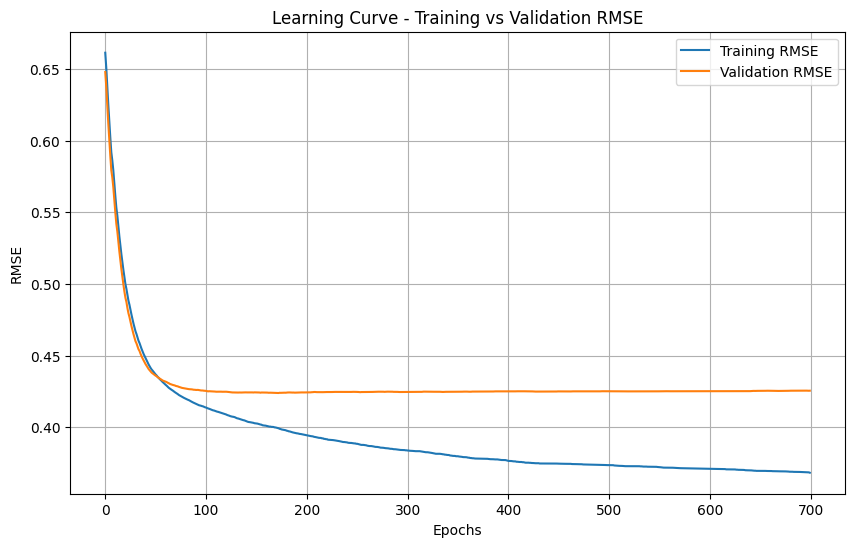

In [7]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Charger les données
df = pd.DataFrame(data)

categorical_cols = ['Marque', 'Module', 'Auto_manuel', 'Carburant', 'Eat']
numerical_cols = ['Kilomtrage', 'Annee', 'Puissance_fiscale', 'Nombre_de_portes']
    # Définir les caractéristiques et la variable cible
X = df[categorical_cols + numerical_cols]
y = df["Prix"]

    # Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    # Meilleurs hyperparamètres trouvés
best_params = {
    'n_estimators': 700,
    'learning_rate': 0.04,
    'max_depth': 7,
    'subsample': 0.9,
    'min_child_weight': 2,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1
}

    # Modèle XGBoost avec les meilleurs paramètres
model = xgb.XGBRegressor(**best_params, random_state=42)

    # Entraînement du modèle sans early stopping
    # Entraînement du modèle sans early stopping
model.fit(X_train, y_train, 
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)  # No need for eval_metric


    # Prédictions sur les données de test
y_pred = model.predict(X_test)
print("the prediction ", y_pred)

    # Évaluation
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

    # Affichage des performances
print("🔍 Évaluation du modèle XGBoost")
print(f"✅ Accuracy (R² Score)        : {r2:.2f}")
print(f"📉 Mean Absolute Error (MAE) : {mae:.2f}")
print(f"📉 Mean Squared Error (MSE)  : {mse:.2f}")
print(f"📉 Root Mean Squared Error   : {rmse:.2f}")

# Sauvegarde du modèle
joblib.dump(model, "../interface/model_xgb.joblib")
print("Modèle sauvegardé sous 'model_xgb.joblib'")

    # Plotting the learning curve
epochs = len(model.evals_result()['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, model.evals_result()['validation_0']['rmse'], label='Training RMSE')
plt.plot(x_axis, model.evals_result()['validation_1']['rmse'], label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Learning Curve - Training vs Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()
